In [1]:
from langchain_openai import ChatOpenAI


In [2]:
from msgpack import os

In [3]:
os.environ["OPENAI_API_BASE"] = "http://127.0.0.1:1234/v1"
os.environ["OPENAI_API_KEY"] = "lm_studio"

In [4]:
llm = ChatOpenAI(model="qwen3-1.7b@q6_k")

In [5]:
from pydantic import BaseModel, Field

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="requete qui optimise la recherche web.")
    justification: str = Field(None, description="pourquoi cette requete est-elle importante ? pour la demande de l'utilisateur ?")


structured_llm = llm.with_structured_output(SearchQuery)


output = structured_llm.invoke("comment le calcium CT score avec le cancer ?")

print(output.search_query)
print(output.justification)

calcium ct score and cancer risk
The search query is related to the association between calcium CT score and cancer risk. The justification for this search query is that it focuses on the relationship between calcium CT scores, which are derived from CT scans, and their potential link with cancer development or progression.


# pattern 1: prompt chaining

lorsque le llm traite la sortie du llm précedent

In [6]:
from langgraph.graph import END , START, StateGraph

In [7]:
from typing_extensions import TypedDict, cast

class State(TypedDict):
   topic: str
   joke: str
   improved_joke: str
   final_joke: str

#noeuds
def generate_joke(state: State) -> State:
   """"premier appel llm pour generer une blague sur un sujet donné"""

   msg = llm.invoke(f"Ecris une courte blague sur {state['topic']}")
   state['joke'] = f"{msg.content}"
   return state


def check_punchline(state: State) -> str:
   """fonction pour verifier si la blague a une punchline"""
   #si la blaque contient "?" ou "!"

   if "?" in state["joke"] or "!" in state["joke"]:
      return "pass"
   return "fail"

def improve_joke(state: State) -> State:
   """second appel du llm pour améliorer la blague en """

   msg = llm.invoke(f"Rend le blague plus amusante en ajoutant des jeux de mots: {state['joke']}")
   state['improved_joke'] = f"{msg.content}"

   return state

def polish_joke(state: State) -> State:
   """troisième appel du llm pour l blague finale"""

   msg = llm.invoke(f"Ajoute une surprise à cette blague: {state['improved_joke']}")
   state['final_joke'] = f"{msg.content}"

   return state



construction du wroflow

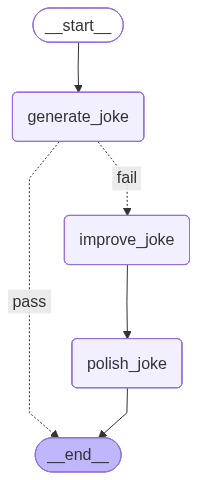

In [8]:
workflow = StateGraph(State)
#ajout des noeuds
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

#connecter chaque noeud

workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges("generate_joke", check_punchline, {"fail": "improve_joke", "pass": END})
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

chain = workflow.compile()

#show workflow


from IPython.display import Image, display
display(Image(chain.get_graph().draw_mermaid_png()))



In [ ]:
state = chain.invoke(State({"topic": "les chats", "joke":"",  "improved_joke":"", "final_joke":""}))

print("Blague initiale:")
print(state['joke'])
print("\n.................\n")

if state['improved_joke']:
    print("improved joke:")
    print(state['improved_joke'])
    print("\n.................\n")

    print("final joke:")

    print(state["final_joke"])

else:
    print("final joke:")
    print(state["final_joke"])
